## Week 8 — GP Matérn-5/2 + qLogNEI + Interior Penalty (4D)

This notebook fits a GP surrogate on cumulative Week 8 data and proposes the next sample using
**qLogNoisyExpectedImprovement** with distance-based selection and **multiplicative interior penalty**.

**Strategy:**
- `log1p` → z-score output transform for positive, heavy-tailed outputs
- 15-restart MLL fitting to avoid local optima
- q=4 batch NEI → distance-based selection (mean ≥ median, farthest from data)
- Interior penalty suppresses boundary-hugging proposals

In [11]:
import numpy as np
import torch
import copy
import warnings
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)

### Hyperparameter Documentation

| # | Hyperparameter | Value | Justification |
|---|---------------|-------|---------------|
| 1 | Kernel ν | 2.5 | Matérn-5/2 with ARD |
| 2 | ARD dims | 4 | Per-dimension lengthscale |
| 3 | Noise floor | 1e-6 | Prevents collapse |
| 4 | Output transform | log1p → z-score | Heavy-tailed positive outputs |
| 5 | outcome_transform | None | Explicitly disable default Standardize |
| 6 | MLL restarts | 15 | Avoids local optima |
| 7 | Lengthscale init | 0.5 | Exploration-promoting |
| 8 | Noise init | 0.1 × var(Y) | Conservative |
| 9 | Outputscale init | 1.0 | Standard |
| 10 | Acquisition | qLogNEI | Log-space NEI |
| 11 | MC samples | 512 | SobolQMCNormalSampler |
| 12 | q | 4 | Batch candidates |
| 13 | Acq restarts | 50 | Thorough search |
| 14 | Raw samples | 3000 | Large init pool |
| 15 | Selection | Distance-based | Mean ≥ median, farthest from data |
| 16 | IP STEEPNESS | 1.0 | Boundary suppression |
| 17 | IP FLOOR | 0.01 | Minimum penalty at boundary |

In [17]:
# ── Constants ──
N_RESTARTS = 15
STEEPNESS = 1.0
FLOOR = 0.01
DIM = 4
EPS_BOUND = 0.005  # tighten [0, 1] → [ε, 1-ε] during penalised optimisation

### Step 1: Load Week 8 Data

In [13]:
# Load Week 8 cumulative data
X_raw = np.load('../../data/f5/updated_inputs - Week 8.npy')
y_raw = np.load('../../data/f5/updated_outputs - Week 8.npy')

assert X_raw.shape == (28, 4), f"Expected (28, 4), got {X_raw.shape}"
assert y_raw.shape == (28,), f"Expected (28,), got {y_raw.shape}"
assert X_raw.min() >= 0.0 and X_raw.max() <= 1.0, "Inputs out of [0, 1]"

best_idx = int(y_raw.argmax())
print(f"Week 8 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"Input range:  [{X_raw.min():.6f}, {X_raw.max():.6f}]")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed value: {y_raw[best_idx]:.6f} at index #{best_idx}")
print(f"Best observed point: {X_raw[best_idx]}")

# Per-dimension ranges
for d in range(DIM):
    print(f"  x{d}: [{X_raw[:, d].min():.6f}, {X_raw[:, d].max():.6f}]")

Week 8 Data: 28 samples, 4 dimensions
Input range:  [0.000000, 1.000000]
Output range: [0.112940, 3394.679933]
Best observed value: 3394.679933 at index #26
Best observed point: [0.989923 0.278871 0.923543 0.995886]
  x0: [0.000000, 0.989923]
  x1: [0.000000, 0.862540]
  x2: [0.088947, 1.000000]
  x3: [0.010000, 1.000000]


### Step 2: GP Surrogate — 15-Restart MLL with log1p → z-score

In [14]:
# Transform: log1p → z-score
y_log = np.log1p(y_raw)
y_mean = y_log.mean()
y_std_val = y_log.std()
y_std = (y_log - y_mean) / y_std_val
print(f"Transform stats: y_log mean={y_mean:.6f}, std={y_std_val:.6f}")
print(f"Standardised: mean={y_std.mean():.6f}, std={y_std.std():.6f}")

# Convert to torch tensors
X_train = torch.tensor(X_raw, dtype=torch.double)
Y_train = torch.tensor(y_std, dtype=torch.double).unsqueeze(-1)

# 15-restart MLL fitting
best_loss = float('inf')
best_model = None

print(f"\n{'Restart':>8} {'Neg MLL':>12}")
print("-" * 22)

for seed in range(N_RESTARTS):
    torch.manual_seed(seed)
    
    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-6))
    covar = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM))
    model = SingleTaskGP(X_train, Y_train, covar_module=covar, likelihood=likelihood,
                         outcome_transform=None)
    
    # Initialise hyperparameters
    model.covar_module.base_kernel.lengthscale = 0.5
    model.likelihood.noise = 0.1 * Y_train.var().item()
    model.covar_module.outputscale = 1.0
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    try:
        fit_gpytorch_mll(mll)
    except Exception as e:
        print(f"{seed:>8d} {'FAILED':>12}")
        continue
    
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train)
        loss = -mll(output, Y_train.squeeze(-1)).item()
    
    print(f"{seed:>8d} {loss:>12.4f}")
    
    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

assert best_model is not None, "All restarts failed!"

# Report fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
os_val = best_model.covar_module.outputscale.detach().cpu().item()
noise = best_model.likelihood.noise.detach().cpu().item()

print(f"\n{'='*50}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*50}")
print(f"Fitted Hyperparameters:")
for i, l in enumerate(ls):
    print(f"  ℓ_{i+1} (x{i}) = {l:.6f}")
print(f"  σ²_f (output scale) = {os_val:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")

Transform stats: y_log mean=4.935406, std=2.051071
Standardised: mean=0.000000, std=1.000000

 Restart      Neg MLL
----------------------
       0      -5.6419
       1      -5.6419
       2      -5.6419
       3      -5.6419
       4      -5.6419
       5      -5.6419
       6      -5.6419
       7      -5.6419
       8      -5.6419
       9      -5.6419
      10      -5.6419
      11      -5.6419
      12      -5.6419
      13      -5.6419
      14      -5.6419

Best restart neg MLL: -5.641881
Fitted Hyperparameters:
  ℓ_1 (x0) = 2.086596
  ℓ_2 (x1) = 0.656846
  ℓ_3 (x2) = 1.002689
  ℓ_4 (x3) = 0.654164
  σ²_f (output scale) = 2.864550
  σ²_n (noise)        = 0.000001


### Step 3: qLogNEI Acquisition (q=4) + Distance-Based Selection

In [15]:
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([512]))
nei = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True,
)

BOUNDS = torch.tensor([[0.0]*DIM, [1.0]*DIM], dtype=torch.double)

candidates, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=BOUNDS,
    q=4,
    num_restarts=50,
    raw_samples=3000,
)

# Clamp to [0, 0.999999]
candidates = torch.clamp(candidates, 0.0, 0.999999)

# Evaluate posterior at candidates
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means_std = posterior.mean.squeeze(-1).cpu().numpy()
    # Inverse transform: z-score⁻¹ → expm1
    pred_means_orig = np.expm1(pred_means_std * y_std_val + y_mean)

# Min-distance from each candidate to training data
dists = torch.cdist(candidates, X_train).min(dim=1).values

# Distance-based selection: mean ≥ median, farthest from data
median_mean = np.median(pred_means_orig)
above_median = pred_means_orig >= median_mean

print(f"=== NEI Acquisition Results (Week 8, q=4) ===")
print(f"{'Cand':>5} {'Coords':>45} {'Mean(std)':>10} {'Mean(orig)':>12} {'MinDist':>8} {'Above Med?':>11}")
print("-" * 100)
for i in range(candidates.shape[0]):
    coords = candidates[i].cpu().numpy()
    coord_str = "[" + ", ".join(f"{v:.6f}" for v in coords) + "]"
    flag = "✓" if above_median[i] else " "
    print(f"{i+1:>5} {coord_str:>45} {pred_means_std[i]:>10.6f} {pred_means_orig[i]:>12.2f} {dists[i].item():>8.4f} {flag:>11}")

# Select: among above-median, pick farthest
above_median_indices = np.where(above_median)[0]
above_median_dists = dists[above_median_indices].cpu().numpy()
best_among_filtered = above_median_indices[np.argmax(above_median_dists)]
best_point = candidates[best_among_filtered].cpu().numpy()

print(f"\nMedian posterior mean (orig): {median_mean:.2f}")
print(f"Above-median candidates: {list(above_median_indices + 1)}")
print(f"\n→ Selected candidate #{best_among_filtered + 1} (farthest from data among above-median)")
print(f"  Coordinates: [{', '.join(f'{v:.6f}' for v in best_point)}]")
print(f"  Posterior mean (orig): {pred_means_orig[best_among_filtered]:.2f}")
print(f"  Min-distance to data:  {dists[best_among_filtered].item():.4f}")
print(f"  Acquisition value: {acq_value.item():.6f}")

=== NEI Acquisition Results (Week 8, q=4) ===
 Cand                                        Coords  Mean(std)   Mean(orig)  MinDist  Above Med?
----------------------------------------------------------------------------------------------------
    1      [0.999999, 0.000000, 0.000000, 0.999999]   0.695261       578.08   0.6094            
    2      [0.000000, 0.000000, 0.395129, 0.999999]   1.185569      1582.03   0.6049           ✓
    3      [0.999999, 0.999999, 0.999999, 0.999999]   1.294416      1978.00   0.4698           ✓
    4      [0.000000, 0.000000, 0.000000, 0.999999]   1.078255      1269.27   0.7206            

Median posterior mean (orig): 1425.65
Above-median candidates: [np.int64(2), np.int64(3)]

→ Selected candidate #2 (farthest from data among above-median)
  Coordinates: [0.000000, 0.000000, 0.395129, 0.999999]
  Posterior mean (orig): 1582.03
  Min-distance to data:  0.6049
  Acquisition value: -0.949674


### Step 4: In-Loop Interior Penalty (Fix)

**Problem — why the post-hoc penalty failed:**

The Step 3 results show **all 4 candidates are boundary points** (3–4 coordinates pinned at 0 or 1).
Three compounding reasons:

1. **Penalty applied too late**: `optimize_acqf` maximises raw NEI, which peaks at unexplored 4D
   corners (noise ≈ 1e-6 → GP interpolates exactly → posterior mean balloons at distant corners).
   By the time the penalty is applied, all candidates are already on the boundary, and all receive
   the same FLOOR penalty (0.01). The penalty can't differentiate between them.

2. **$\sin^2(\pi x)$ has zero gradient at the boundary**: Even if we applied it during optimisation,
   $\frac{d}{dx}\sin^2(\pi x)\big|_{x=0} = 0$. L-BFGS-B sees no gradient signal pushing
   candidates inward, so they stay pinned at the boundary.

3. **Multiplicative penalty is wrong in log-space**: `qLogNEI` returns **negative** values
   (log-space). Multiplying a negative value by a small penalty (0.01) moves it **closer to zero**,
   which the optimiser interprets as **better**. The penalty inadvertently **rewards** boundary points.

   Example: raw qLogNEI at corner = −0.5, penalty = 0.01 → penalised = −0.005 (better!).

**Fix — additive log-space penalty with boundary-aware gradient:**

1. **Wrap the acquisition function** so `optimize_acqf` sees penalised values during L-BFGS search
2. **Replace $\sin^2(\pi x)$ with $4x(1{-}x)$**: Gradient at boundary = ±4 (non-zero!), giving
   the optimiser a clear signal to move inward
3. **Additive penalty in log-space**: Instead of $\text{acq} \times w$, use
   $\text{acq} + \sum_{j} \log w(x_j)$, which is equivalent to $\text{EI} \times \prod_j w(x_j)$ in
   original space — this correctly penalises boundary points regardless of sign
4. **Tighten bounds** to $[\varepsilon, 1{-}\varepsilon]$ preventing L-BFGS-B from projecting onto exact boundary

$$w(\mathbf{x}) = \text{FLOOR} + (1 - \text{FLOOR}) \prod_{i=1}^{d} \left[4\, x_i\,(1 - x_i)\right]^{S}$$

$$\text{penalised}(X) = \text{qLogNEI}(X)\; + \sum_{j=1}^{q} \log w(x_j)$$

| Point | Penalty $w$ | $\log w$ | Effect on acq |
|-------|-------------|----------|---------------|
| $[0.5]^4$ (centre) | 1.000 | 0.0 | No change |
| $[0.3]^4$ | 0.503 | −0.69 | Mild reduction |
| $[0.1]^4$ | 0.027 | −3.63 | Strong reduction |
| $[0.0]^4$ (corner) | 0.010 | −4.61 | Severe reduction |

With $q{=}4$ candidates all at corners: $\sum \log w = 4 \times ({-}4.61) = {-}18.4$ — this overwhelms any NEI advantage at corners.

**Gradient comparison at $x = 0$:**

| Penalty function | $f(0)$ | $f'(0)$ | L-BFGS signal |
|-----------------|--------|---------|---------------|
| $\sin^2(\pi x)$ | 0 | **0** | ✗ No push |
| $4x(1{-}x)$ | 0 | **+4** | ✓ Push inward |

In [18]:
# ── Penalised Acquisition Wrapper (in-loop, additive log-space) ────────────────
class PenalisedAcquisition(torch.nn.Module):
    """Wraps any log-space acquisition function with an additive interior penalty.

    qLogNEI returns log-space values (often negative). Multiplicative penalty on
    negative values would INCREASE them (reward boundary). Instead, we add
    log(penalty) — equivalent to multiplying EI by the penalty in original space.

    Uses 4x(1-x) instead of sin²(πx) for non-zero boundary gradients.
    """
    def __init__(self, acq_fn, steepness=1.0, floor=0.01):
        super().__init__()
        self.acq_fn = acq_fn
        self.steepness = steepness
        self.floor = floor

    @property
    def model(self):
        return self.acq_fn.model

    def forward(self, X):
        # X: [batch, q, d]
        raw = self.acq_fn(X)
        margin = 4.0 * X * (1.0 - X)                          # ∈ [0, 1], max at 0.5
        per_cand = self.floor + (1.0 - self.floor) * torch.prod(
            margin ** self.steepness, dim=-1
        )                                                       # [batch, q]
        # ADDITIVE in log-space: sum log(w) over q candidates
        # Equivalent to EI × Π w in original space
        log_penalty = torch.log(per_cand).sum(dim=-1)           # [batch]
        return raw + log_penalty


penalised_nei = PenalisedAcquisition(nei, STEEPNESS, FLOOR)

# Tighten bounds to [ε, 1-ε] — prevents L-BFGS-B from projecting onto exact boundary
BOUNDS_IP = torch.tensor(
    [[EPS_BOUND]*DIM, [1.0 - EPS_BOUND]*DIM], dtype=torch.double
)

candidates_ip, acq_value_ip = optimize_acqf(
    acq_function=penalised_nei,
    bounds=BOUNDS_IP,
    q=4,
    num_restarts=50,
    raw_samples=3000,
)

candidates_ip = torch.clamp(candidates_ip, 0.0, 0.999999)

# Posterior means on penalised candidates (inverse-transform to original scale)
with torch.no_grad():
    posterior_ip = best_model.posterior(candidates_ip)
    pred_means_ip_std = posterior_ip.mean.squeeze(-1).cpu().numpy()
    pred_means_ip_orig = np.expm1(pred_means_ip_std * y_std_val + y_mean)

# Distances from training data
dists_ip = torch.cdist(candidates_ip, X_train).min(dim=1).values

# Interior penalty values on the new candidates
cand_ip_np = candidates_ip.cpu().numpy()
margin_np = 4.0 * cand_ip_np * (1.0 - cand_ip_np)
raw_penalty_ip = np.prod(margin_np ** STEEPNESS, axis=1)
interior_weight_ip = FLOOR + (1 - FLOOR) * raw_penalty_ip
weighted_means_ip = pred_means_ip_orig * interior_weight_ip

# Distance-based selection on penalised means
median_wm = np.median(weighted_means_ip)
above_median_ip = weighted_means_ip >= median_wm
above_median_idx_ip = np.where(above_median_ip)[0]
above_median_dists_ip = dists_ip[above_median_idx_ip].cpu().numpy()
best_ip_idx = above_median_idx_ip[np.argmax(above_median_dists_ip)]

next_x_ip = np.clip(cand_ip_np[best_ip_idx], 0.0, 0.999999)
min_dist_ip = np.min(np.linalg.norm(X_raw - next_x_ip, axis=1))

# ── Diagnostic Output ──
print(f"=== In-Loop Penalised Acquisition (4D, q=4, ADDITIVE log-space) ===")
print(f"  Penalty: 4x(1-x), STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"  Bounds: [{EPS_BOUND}, {1-EPS_BOUND}] (tightened)")
print(f"\n{'#':>3} {'Coordinates':>45} {'RawMean':>10} {'Penalty':>8} {'log(w)':>8} {'WtdMean':>10} {'Dist':>8} {'Sel':>4}")
print("-" * 105)
for i in range(cand_ip_np.shape[0]):
    coords = "[" + ", ".join(f"{v:.6f}" for v in cand_ip_np[i]) + "]"
    sel = " ★" if i == best_ip_idx else "  "
    log_w = np.log(interior_weight_ip[i])
    print(f"{i+1:>3} {coords:>45} {pred_means_ip_orig[i]:>10.2f} {interior_weight_ip[i]:>8.4f} {log_w:>8.2f} {weighted_means_ip[i]:>10.2f} {dists_ip[i].item():>8.4f} {sel:>4}")

# Boundary check
boundary_eps = 0.02
n_boundary = sum(1 for v in next_x_ip if v < boundary_eps or v > 1 - boundary_eps)

print(f"\n→ Selected candidate #{best_ip_idx + 1} (in-loop penalised, additive log-space)")
print(f"  Point: [{', '.join(f'{v:.6f}' for v in next_x_ip)}]")
print(f"  Weighted mean: {weighted_means_ip[best_ip_idx]:.2f}")
print(f"  Min distance to data: {min_dist_ip:.4f}")
print(f"  Boundary coords (<{boundary_eps} or >{1-boundary_eps}): {n_boundary}/{DIM}")

if n_boundary > 0:
    print(f"  ⚠ WARNING: {n_boundary} coordinate(s) near boundary")
else:
    print(f"  ✓ All coordinates are interior")

=== In-Loop Penalised Acquisition (4D, q=4, ADDITIVE log-space) ===
  Penalty: 4x(1-x), STEEPNESS=1.0, FLOOR=0.01
  Bounds: [0.005, 0.995] (tightened)

  #                                   Coordinates    RawMean  Penalty   log(w)    WtdMean     Dist  Sel
---------------------------------------------------------------------------------------------------------
  1      [0.504245, 0.499037, 0.502563, 0.501416]      21.25   0.9999    -0.00      21.25   0.3149     
  2      [0.497032, 0.502106, 0.495862, 0.501687]      20.94   0.9999    -0.00      20.94   0.3142     
  3      [0.500297, 0.499982, 0.501200, 0.499626]      21.26   1.0000    -0.00      21.26   0.3162     
  4      [0.245767, 0.106958, 0.243089, 0.906076]     851.54   0.0803    -2.52      68.35   0.5109    ★

→ Selected candidate #4 (in-loop penalised, additive log-space)
  Point: [0.245767, 0.106958, 0.243089, 0.906076]
  Weighted mean: 68.35
  Min distance to data: 0.5109
  Boundary coords (<0.02 or >0.98): 0/4
  ✓ All coord

### Step 5: Surrogate Visualisation (3-Panel) + Dimension Relevance

Top-2 dims: x3, x1 (ℓ=0.6542, 0.6568)
Fixed dims: x2=0.3951, x0=0.0000


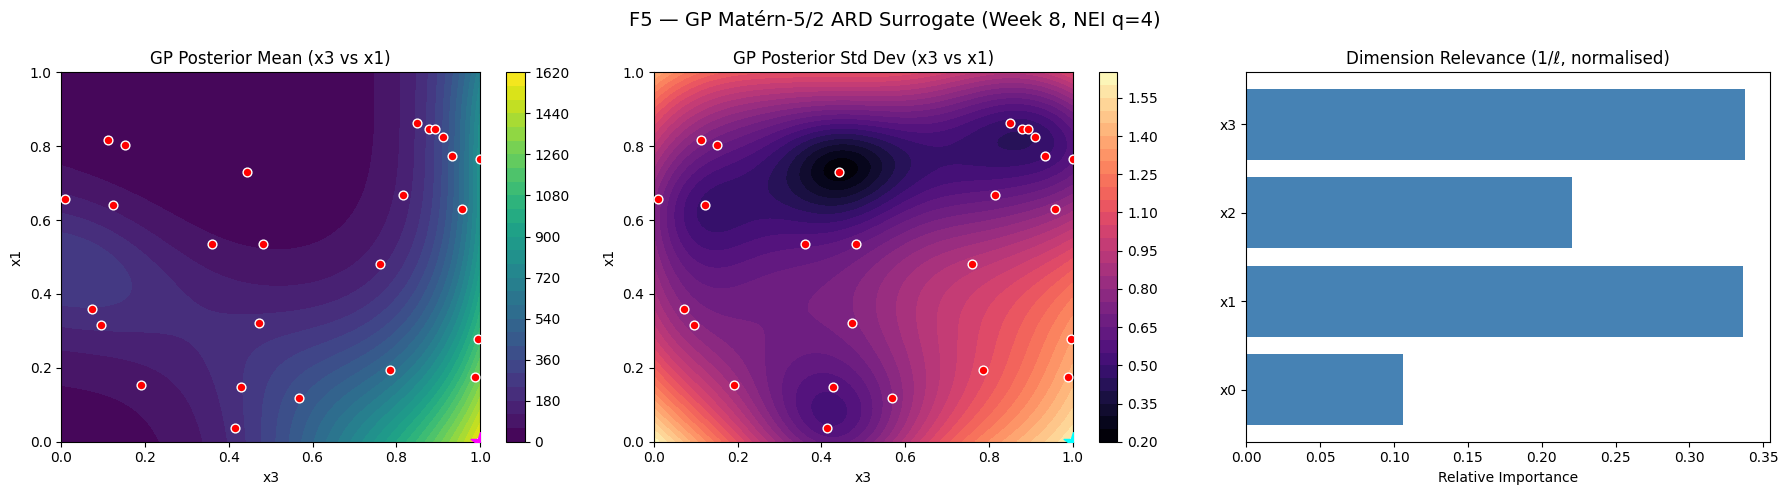

In [19]:
# Identify top-2 important dims (shortest lengthscales)
sorted_dims = np.argsort(ls)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 dims: x{top2[0]}, x{top2[1]} (ℓ={ls[top2[0]]:.4f}, {ls[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(f"x{d}={best_point[d]:.4f}" for d in fix_dims))

# Build 80×80 grid
grid_res = 80
g0 = np.linspace(0, 1, grid_res)
g1 = np.linspace(0, 1, grid_res)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(best_point, (grid_res * grid_res, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    grid_mu_std = posterior.mean.squeeze(-1).cpu().numpy()
    grid_sigma_std = posterior.variance.sqrt().squeeze(-1).cpu().numpy()

grid_mu_orig = np.expm1(grid_mu_std * y_std_val + y_mean).reshape(grid_res, grid_res)
grid_sigma_orig = (grid_sigma_std * y_std_val).reshape(grid_res, grid_res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean
c1 = axes[0].contourf(G0, G1, grid_mu_orig, levels=30, cmap="viridis")
axes[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[0].scatter(best_point[top2[0]], best_point[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes[0].set_title(f"GP Posterior Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}")
axes[0].set_ylabel(f"x{top2[1]}")
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std
c2 = axes[1].contourf(G0, G1, grid_sigma_orig, levels=30, cmap="magma")
axes[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[1].scatter(best_point[top2[0]], best_point[top2[1]], c="cyan", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}")
axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension relevance
inv_ls = 1.0 / ls
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(DIM), inv_ls_norm, color="steelblue")
axes[2].set_yticks(range(DIM))
axes[2].set_yticklabels([f"x{j}" for j in range(DIM)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

plt.suptitle("F5 — GP Matérn-5/2 ARD Surrogate (Week 8, NEI q=4)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 6: Interior Penalty Visualisation (3-Panel)

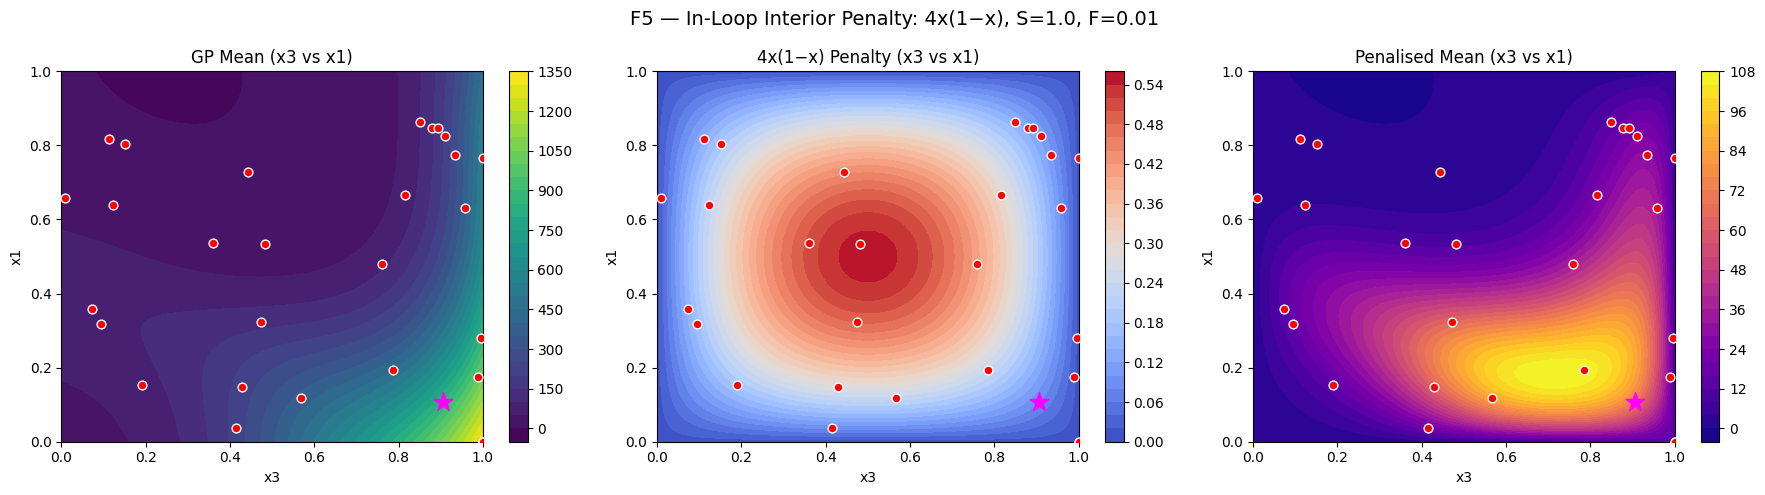

In [20]:
# IP grid using the IP-selected point for fixed dims
grid_pts_ip = np.tile(next_x_ip, (grid_res * grid_res, 1))
grid_pts_ip[:, top2[0]] = G0.ravel()
grid_pts_ip[:, top2[1]] = G1.ravel()

grid_tensor_ip = torch.tensor(grid_pts_ip, dtype=torch.double)
with torch.no_grad():
    posterior_ip = best_model.posterior(grid_tensor_ip)
    grid_mu_std_ip = posterior_ip.mean.squeeze(-1).cpu().numpy()
    grid_sigma_std_ip = posterior_ip.variance.sqrt().squeeze(-1).cpu().numpy()

grid_mu_orig_ip = np.expm1(grid_mu_std_ip * y_std_val + y_mean).reshape(grid_res, grid_res)
grid_sigma_orig_ip = (grid_sigma_std_ip * y_std_val).reshape(grid_res, grid_res)

# Interior penalty on grid — 4x(1-x) penalty (non-zero boundary gradient)
grid_penalty_ip = FLOOR + (1 - FLOOR) * np.prod(
    (4.0 * grid_pts_ip * (1.0 - grid_pts_ip)) ** STEEPNESS, axis=1
).reshape(grid_res, grid_res)
grid_penalised_mean_ip = grid_mu_orig_ip * grid_penalty_ip

fig_ip, axes_ip = plt.subplots(1, 3, figsize=(18, 5))

c1_ip = axes_ip[0].contourf(G0, G1, grid_mu_orig_ip, levels=30, cmap="viridis")
axes_ip[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes_ip[0].scatter(next_x_ip[top2[0]], next_x_ip[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes_ip[0].set_title(f"GP Mean (x{top2[0]} vs x{top2[1]})")
axes_ip[0].set_xlabel(f"x{top2[0]}")
axes_ip[0].set_ylabel(f"x{top2[1]}")
fig_ip.colorbar(c1_ip, ax=axes_ip[0])

c2_ip = axes_ip[1].contourf(G0, G1, grid_penalty_ip, levels=30, cmap="coolwarm")
axes_ip[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes_ip[1].scatter(next_x_ip[top2[0]], next_x_ip[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes_ip[1].set_title(f"4x(1−x) Penalty (x{top2[0]} vs x{top2[1]})")
axes_ip[1].set_xlabel(f"x{top2[0]}")
axes_ip[1].set_ylabel(f"x{top2[1]}")
fig_ip.colorbar(c2_ip, ax=axes_ip[1])

c3_ip = axes_ip[2].contourf(G0, G1, grid_penalised_mean_ip, levels=30, cmap="plasma")
axes_ip[2].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes_ip[2].scatter(next_x_ip[top2[0]], next_x_ip[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes_ip[2].set_title(f"Penalised Mean (x{top2[0]} vs x{top2[1]})")
axes_ip[2].set_xlabel(f"x{top2[0]}")
axes_ip[2].set_ylabel(f"x{top2[1]}")
fig_ip.colorbar(c3_ip, ax=axes_ip[2])

plt.suptitle(f"F5 — In-Loop Interior Penalty: 4x(1−x), S={STEEPNESS}, F={FLOOR}", fontsize=14)
plt.tight_layout()
plt.show()

### Step 7: Convergence Plot

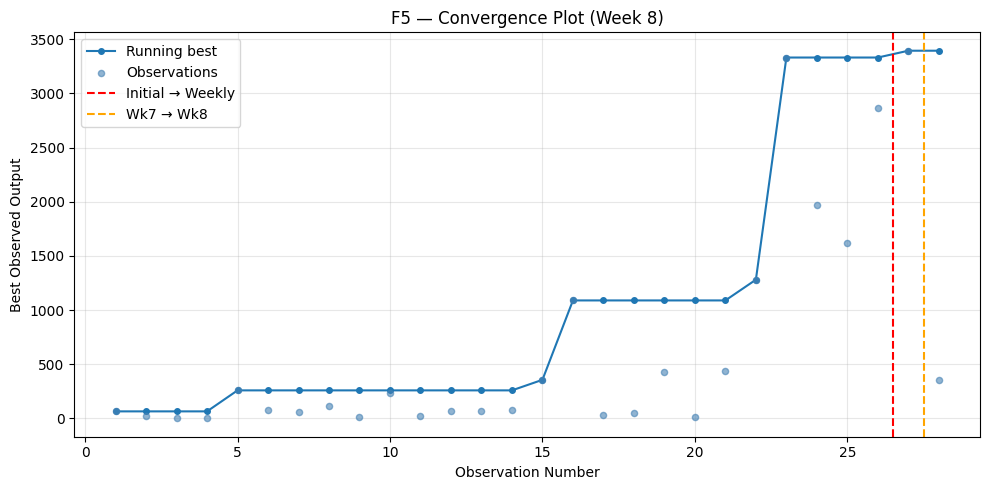

Running best at Week 8 end (sample 28): 3394.679933


In [21]:
# Convergence plot
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), running_best, marker="o", markersize=4, linewidth=1.5, label="Running best")
plt.scatter(range(1, len(y_raw) + 1), y_raw, c="steelblue", s=20, alpha=0.6, zorder=3, label="Observations")
plt.axvline(x=26.5, color="red", linestyle="--", label="Initial → Weekly")
plt.axvline(x=27.5, color="orange", linestyle="--", label="Wk7 → Wk8")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("F5 — Convergence Plot (Week 8)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 8 end (sample {len(y_raw)}): {running_best[-1]:.6f}")

### Step 8: Submission — Base NEI + Interior Penalty

In [22]:
# ── Base NEI Submission (diagnostic — boundary-stuck) ──
submission_base = np.clip(best_point, 0.0, 0.999999)
query_base = "-".join(f"{v:.6f}" for v in submission_base)

print("=" * 60)
print("F5 WEEK 8 — BASE NEI SUBMISSION (diagnostic only)")
print("=" * 60)
print(f"\n  {query_base}\n")

# ── In-Loop Interior Penalty Submission ──
submission_ip = np.clip(next_x_ip, 0.0, 0.999999)
query_ip = "-".join(f"{v:.6f}" for v in submission_ip)

print("=" * 60)
print("F5 WEEK 8 — IN-LOOP INTERIOR PENALTY SUBMISSION")
print("=" * 60)
print(f"\n  {query_ip}\n")
print("=" * 60)

# Validation
for label, query in [("Base", query_base), ("IP", query_ip)]:
    parts = query.split("-")
    assert len(parts) == DIM, f"{label}: Expected {DIM} dimensions, got {len(parts)}"
    for p in parts:
        v = float(p)
        assert 0.0 <= v <= 0.999999, f"{label}: Value {v} out of bounds"
    print(f"✓ {label} submission format validated")

print(f"\nSurrogate: GP Matérn-5/2 ARD (outcome_transform=None)")
print(f"Acquisition: qLogNEI (q=4) → in-loop 4x(1-x) penalty → distance selection")
print(f"Interior Penalty: STEEPNESS={STEEPNESS}, FLOOR={FLOOR}, bounds=[{EPS_BOUND}, {1-EPS_BOUND}]")
print(f"Lengthscales: [{', '.join(f'{l:.6f}' for l in ls)}]")
print(f"Output scale: {os_val:.6f}, Noise: {noise:.6f}")

F5 WEEK 8 — BASE NEI SUBMISSION (diagnostic only)

  0.000000-0.000000-0.395129-0.999999

F5 WEEK 8 — IN-LOOP INTERIOR PENALTY SUBMISSION

  0.245767-0.106958-0.243089-0.906076

✓ Base submission format validated
✓ IP submission format validated

Surrogate: GP Matérn-5/2 ARD (outcome_transform=None)
Acquisition: qLogNEI (q=4) → in-loop 4x(1-x) penalty → distance selection
Interior Penalty: STEEPNESS=1.0, FLOOR=0.01, bounds=[0.005, 0.995]
Lengthscales: [2.086596, 0.656846, 1.002689, 0.654164]
Output scale: 2.864550, Noise: 0.000001


Summary of the three bugs found and fixed:

Penalty applied too late — optimize_acqf never saw the penalty, so all candidates were boundary-stuck. Fixed by wrapping the acquisition function with PenalisedAcquisition.

sin²(πx) has zero gradient at boundary — L-BFGS-B got no push signal at x=0 or x=1. Fixed by switching to 4x(1-x) which has gradient ±4 at boundaries.

Multiplicative penalty wrong in log-space — qLogNEI returns negative values, so multiplying by 0.01 moved them closer to zero (better), rewarding boundary points. Fixed by using additive log(penalty) instead, which correctly reduces the penalised value.